# Défi ÉquiAlgo - analyse des données

Analyse descriptive des deux jeux de données : qualité, distributions, écarts entre groupes
(Centre / Éloignée), taux d'octroi et comparaison historique / candidats.

Ce carnet ne porte que sur les **données**. L'analyse des prédictions (AUC, importance des
variables, équité) est dans `analyse.py`.

In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import ks_2samp

pd.set_option('display.width', 200)

demandes = pd.read_csv('../data/donnees_demandes.csv')
candidats = pd.read_csv('../data/candidats_evaluation.csv')

ELOIGNEES = ['Bas-Saint-Laurent', 'Cote-Nord', 'Gaspesie-Iles-de-la-Madeleine']
NUMERIQUES = ['cote_r_equivalent', 'revenu_familial_estime', 'heures_travail_semaine',
              'distance_domicile_campus_km']
BINAIRES = ['premiere_generation_universitaire']
CATEGORIELLES = ['programme_etudes', 'region_administrative', 'code_postal_3']
GROUPES = ['Centre', 'Eloignee']

for df in (demandes, candidats):
    df['groupe'] = np.where(df['region_administrative'].isin(ELOIGNEES), 'Eloignee', 'Centre')

# Palette categorielle de reference : un role par couleur, partout dans le carnet.
COULEURS_GROUPE = {'Centre': '#2a78d6', 'Eloignee': '#eb6834'}
COULEURS_JEU = {'historique': '#2a78d6', 'candidats': '#1baf7a'}
ENCRE, ENCRE_SECONDAIRE, GRILLE = '#0b0b0b', '#52514e', '#e4e3df'


def styliser(ax, titre=None):
    """Axes discrets : grille legere, sans cadre haut/droite."""
    if titre:
        ax.set_title(titre, color=ENCRE, fontsize=11, loc='left')
    ax.grid(color=GRILLE, lw=0.8)
    ax.set_axisbelow(True)
    for cote in ['top', 'right']:
        ax.spines[cote].set_visible(False)
    ax.tick_params(colors=ENCRE_SECONDAIRE)
    return ax


def formater_milliers(ax, col):
    """Affiche le revenu en milliers de dollars (ex. 50k) pour eviter les chevauchements."""
    if col == 'revenu_familial_estime':
        ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v / 1000:.0f}k'))

## 1. Qualité des données

In [11]:
def resume_colonnes(df):
    """Type, valeurs manquantes, nombre de valeurs distinctes, min et max de chaque colonne."""
    return pd.DataFrame({
        'type': df.dtypes.astype(str),
        'manquantes': df.isna().sum(),
        'distinctes': df.nunique(),
        'min': df.min(numeric_only=True),
        'max': df.max(numeric_only=True),
    }).loc[df.columns]


print(f'Historique : {demandes.shape}, candidats : {candidats.shape}')
print()
print(resume_colonnes(demandes))
print()
print('Doublons de id_candidat (historique, candidats) :',
      demandes['id_candidat'].duplicated().sum(), candidats['id_candidat'].duplicated().sum())
print('Identifiants communs aux deux jeux :',
      len(set(demandes['id_candidat']) & set(candidats['id_candidat'])))
print('Valeurs hors bornes de la cote R (15 a 40) :',
      (~demandes['cote_r_equivalent'].between(15, 40)).sum())
print('Valeurs negatives (revenu, heures, distance) :',
      (demandes[['revenu_familial_estime', 'heures_travail_semaine', 'distance_domicile_campus_km']] < 0).sum().to_dict())

Historique : (10000, 12), candidats : (4000, 10)

                                      type  manquantes  distinctes       min        max
id_candidat                            str           0       10000       NaN        NaN
cote_r_equivalent                  float64           0        1487     16.78      38.41
programme_etudes                       str           0           5       NaN        NaN
region_administrative                  str           0           5       NaN        NaN
code_postal_3                          str           0          18       NaN        NaN
revenu_familial_estime               int64           0        9496  13364.00  293879.00
heures_travail_semaine               int64           0          27      1.00      29.00
distance_domicile_campus_km        float64           0        2972      0.10     748.20
premiere_generation_universitaire    int64           0           2      0.00       1.00
decision_octroi                      int64           0           2    

**Lecture.** Les données sont propres : aucune valeur manquante, aucun doublon, aucun identifiant
commun aux deux jeux, aucune valeur hors bornes. Elles sont synthétiques, donc le travail porte sur
les distributions et le biais, pas sur le nettoyage.

## 2. Distributions des variables numériques

Statistiques par groupe, puis histogrammes superposés. L'**asymétrie** (skewness) signale les
variables à longue queue, qu'une transformation log peut stabiliser.

                                       moyenne  ecart_type       min       q25   mediane       q75        max  asymetrie
cote_r_equivalent           Centre       27.99        2.99     17.63     25.96     27.98     30.06      38.41       0.03
                            Eloignee     27.33        2.98     16.78     25.35     27.29     29.36      37.39       0.00
revenu_familial_estime      Centre    76056.29    33540.65  17200.00  52468.50  69175.50  92187.00  293879.00       1.42
                            Eloignee  56330.32    25563.62  13364.00  38152.50  51561.50  69079.00  224129.00       1.29
heures_travail_semaine      Centre        8.97        2.98      1.00      7.00      9.00     11.00      24.00       0.32
                            Eloignee     13.02        3.61      3.00     10.00     13.00     15.00      29.00       0.30
distance_domicile_campus_km Centre       19.79       13.27      0.10      9.90     17.00     26.70     129.70       1.29
                            Eloi

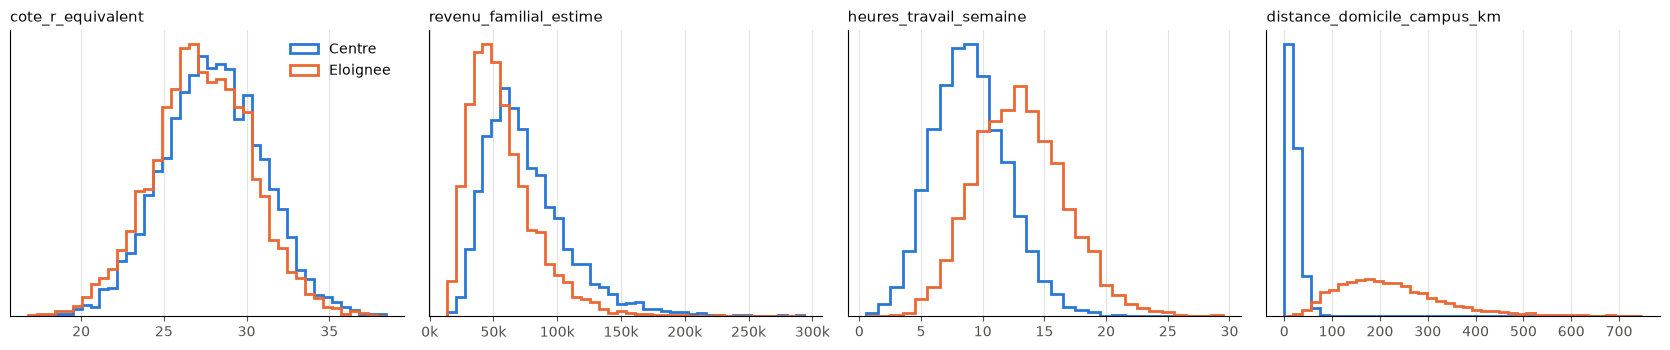

In [4]:
def stats_par_groupe(df, colonnes, groupe='groupe'):
    """Moyenne, ecart-type, quartiles et asymetrie de chaque colonne, par groupe."""
    lignes = {}
    for col in colonnes:
        for g, s in df.groupby(groupe)[col]:
            lignes[(col, g)] = {
                'moyenne': s.mean(), 'ecart_type': s.std(), 'min': s.min(),
                'q25': s.quantile(0.25), 'mediane': s.median(), 'q75': s.quantile(0.75),
                'max': s.max(), 'asymetrie': s.skew(),
            }
    return pd.DataFrame(lignes).T


def tracer_distributions(df, colonnes, groupe='groupe', couleurs=COULEURS_GROUPE, bins=40):
    """Histogrammes normalises (densite) de chaque colonne, un par groupe, sur des bacs communs."""
    fig, axes = plt.subplots(1, len(colonnes), figsize=(4.2 * len(colonnes), 3.6))
    for ax, col in zip(np.atleast_1d(axes), colonnes):
        if pd.api.types.is_integer_dtype(df[col]) and df[col].nunique() <= 50:
            # Entier a peu de valeurs : un bac par valeur, sinon des bacs vides creent des trous.
            bacs = np.arange(df[col].min() - 0.5, df[col].max() + 1.5)
        else:
            bacs = np.histogram_bin_edges(df[col], bins=bins)
        for g, couleur in couleurs.items():
            ax.hist(df.loc[df[groupe] == g, col], bins=bacs, density=True, histtype='step',
                    lw=2, color=couleur, label=g)
        styliser(ax, col)
        formater_milliers(ax, col)
        ax.set_yticks([])
    np.atleast_1d(axes)[0].legend(frameon=False)
    plt.tight_layout()
    plt.show()


print(stats_par_groupe(demandes, NUMERIQUES).round(2))
tracer_distributions(demandes, NUMERIQUES)

In [5]:
# Chevauchement des distributions entre groupes (support commun).
def chevauchement(df, col, groupe='groupe'):
    """Part de chaque groupe comprise dans l'etendue [min, max] de l'autre groupe."""
    a, b = (df.loc[df[groupe] == g, col] for g in GROUPES)
    return pd.Series({
        f'{GROUPES[0]} dans etendue {GROUPES[1]}': a.between(b.min(), b.max()).mean(),
        f'{GROUPES[1]} dans etendue {GROUPES[0]}': b.between(a.min(), a.max()).mean(),
    }, name=col)


print(pd.concat([chevauchement(demandes, c) for c in NUMERIQUES], axis=1).T.round(3))

                             Centre dans etendue Eloignee  Eloignee dans etendue Centre
cote_r_equivalent                                   0.999                         1.000
revenu_familial_estime                              0.997                         0.995
heures_travail_semaine                              0.992                         0.998
distance_domicile_campus_km                         0.572                         0.208


**Lecture.**
- **Cote R** : distribution quasi normale (asymétrie d'environ 0) et de même forme dans les deux
  groupes. Le décalage de moyenne est faible (27.3 contre 28.0, soit 0.2 écart-type).
- **Revenu** : queue longue à droite (asymétrie de 1.3 à 1.4). Il est environ 20 k$ plus bas en
  région (médiane de 52 k$ contre 69 k$).
- **Heures travaillées** : variable entière, environ 4 h de plus par semaine en région (13 contre 9).
- **Distance** : presque disjointe. La médiane est de 205 km en région contre 17 km au Centre, et
  seuls 21 % des dossiers éloignés tombent dans l'étendue du Centre (0 à 130 km). Il n'y a donc pas de
  support commun : tout modèle qui compare les groupes à distance égale extrapole.

## 3. Variables binaires et catégorielles

In [6]:
def repartition(df, col, groupe='groupe'):
    """Effectifs et proportions (en colonne) d'une variable categorielle, par groupe."""
    effectifs = pd.crosstab(df[col], df[groupe], margins=True, margins_name='total')
    proportions = pd.crosstab(df[col], df[groupe], normalize='columns')
    return pd.concat({'effectif': effectifs, 'proportion': proportions}, axis=1)


for col in BINAIRES + ['programme_etudes', 'region_administrative']:
    print(repartition(demandes, col).round(3))
    print()

cp = demandes.groupby('code_postal_3')['groupe'].agg(['size', pd.Series.nunique])
print(f"code_postal_3 : {len(cp)} valeurs, de {cp['size'].min()} a {cp['size'].max()} dossiers chacune")
print('Codes postaux presents dans les deux groupes :', (cp['nunique'] > 1).sum())
print('Codes postaux des candidats absents de l\'historique :',
      len(set(candidats['code_postal_3']) - set(demandes['code_postal_3'])))

                                  effectif                 proportion         
groupe                              Centre Eloignee  total     Centre Eloignee
premiere_generation_universitaire                                             
0                                     4411     2224   6635      0.735    0.556
1                                     1589     1776   3365      0.265    0.444
total                                 6000     4000  10000        NaN      NaN

                  effectif                 proportion         
groupe              Centre Eloignee  total     Centre Eloignee
programme_etudes                                              
Arts et lettres        915      808   1723      0.152    0.202
Genie                 1518      774   2292      0.253    0.194
Sante                 1032      750   1782      0.172    0.188
Sciences              1350      779   2129      0.225    0.195
Sciences sociales     1185      889   2074      0.198    0.222
total                

**Lecture.**
- **Première génération** : 44 % en région contre 27 % au Centre.
- **Programmes** : la répartition diffère peu entre groupes (au plus 5 points, Arts et lettres et
  Genie).
- **Codes postaux** : chacun des 18 codes appartient à un seul groupe. `code_postal_3` determine donc
  exactement le groupe : c'est un proxy parfait de la région.

## 4. Taux d'octroi

`décision_octroi` est la décision du comité, pas le merite : ces taux décrivent le comportement
historique à auditer.

In [7]:
def taux_octroi_par(df, col, cible='decision_octroi'):
    """Effectif et taux d'octroi par modalite de `col`."""
    return df.groupby(col)[cible].agg(effectif='size', taux_octroi='mean')


print(f"Taux d'octroi global : {demandes['decision_octroi'].mean():.3f}")
print()
for col in ['groupe', 'region_administrative', 'programme_etudes', 'premiere_generation_universitaire']:
    print(taux_octroi_par(demandes, col).round(3))
    print()
print(pd.crosstab(demandes['programme_etudes'], demandes['groupe'],
                  values=demandes['decision_octroi'], aggfunc='mean').round(3))

Taux d'octroi global : 0.399

          effectif  taux_octroi
groupe                         
Centre        6000        0.484
Eloignee      4000        0.273

                               effectif  taux_octroi
region_administrative                               
Bas-Saint-Laurent                  1293        0.269
Capitale-Nationale                 1999        0.484
Cote-Nord                          1178        0.263
Gaspesie-Iles-de-la-Madeleine      1529        0.284
Montreal                           4001        0.483

                   effectif  taux_octroi
programme_etudes                        
Arts et lettres        1723        0.365
Genie                  2292        0.428
Sante                  1782        0.393
Sciences               2129        0.413
Sciences sociales      2074        0.388

                                   effectif  taux_octroi
premiere_generation_universitaire                       
0                                      6635        0.413
1         

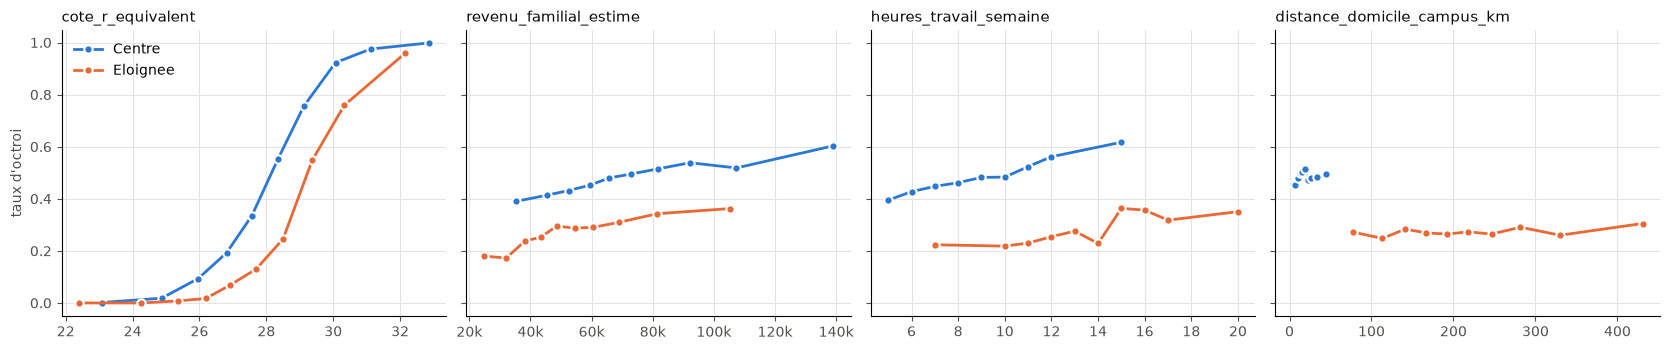

In [8]:
def tracer_taux_par_quantile(df, colonnes, groupe='groupe', cible='decision_octroi', q=10):
    """Taux d'octroi par decile de chaque variable, une courbe par groupe.

    Les deciles sont calcules dans chaque groupe : chaque point regroupe environ 10 % du
    groupe, meme quand les distributions se chevauchent peu (distance).
    """
    fig, axes = plt.subplots(1, len(colonnes), figsize=(4.2 * len(colonnes), 3.6), sharey=True)
    for ax, col in zip(np.atleast_1d(axes), colonnes):
        for g, couleur in COULEURS_GROUPE.items():
            s = df[df[groupe] == g]
            bacs = pd.qcut(s[col], q=q, duplicates='drop')
            points = s.groupby(bacs, observed=True).agg(x=(col, 'median'), taux=(cible, 'mean'))
            ax.plot(points['x'], points['taux'], '-o', color=couleur, lw=2, ms=6, mec='white', mew=1.5, label=g)
        styliser(ax, col)
        formater_milliers(ax, col)
    np.atleast_1d(axes)[0].set_ylabel("taux d'octroi", color=ENCRE_SECONDAIRE)
    np.atleast_1d(axes)[0].legend(frameon=False)
    plt.tight_layout()
    plt.show()


tracer_taux_par_quantile(demandes, NUMERIQUES)

**Lecture.**
- L'écart d'environ 21 points est **uniforme** : les trois régions éloignées sont entre 26 et 28 %, les
  deux centres à 48 %, et l'écart vaut 19 à 21 points dans chaque programme. C'est la signature d'une
  pénalité constante liée à la région, pas d'un effet de programme.
- **À cote R égale**, la courbe des régions éloignées est décalée d'environ un point de cote R vers la
  droite : le groupe eloigne doit avoir une meilleure cote pour le même taux d'octroi.
- **Dans chaque groupe**, le taux d'octroi augmente avec le revenu et avec les heures travaillées. La
  distance n'a pas d'effet à l'intérieur d'un groupe : elle n'agit qu'à travers la région.

## 5. Corrélations

Corrélations de Spearman (robustes aux queues longues) entre les variables numériques, l'indicateur
de région et la décision.

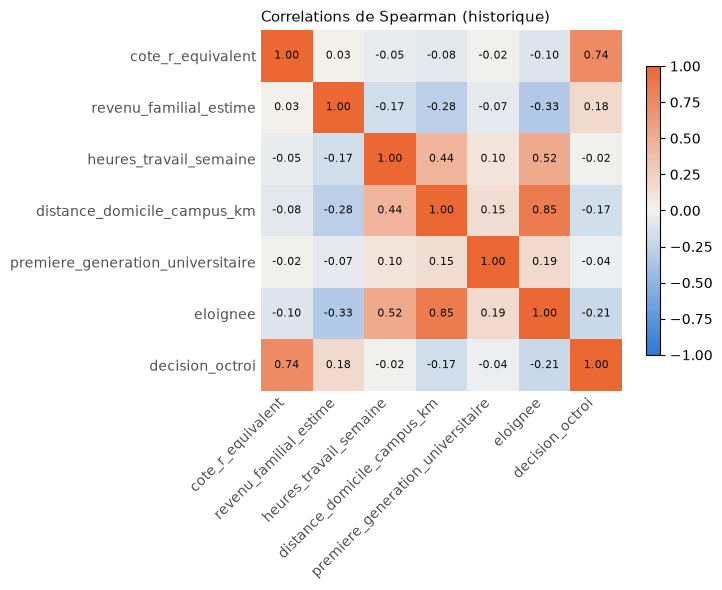

                                   eloignee  decision_octroi
cote_r_equivalent                    -0.104            0.736
revenu_familial_estime               -0.327            0.182
heures_travail_semaine                0.520           -0.016
distance_domicile_campus_km           0.845           -0.169
premiere_generation_universitaire     0.186           -0.038
eloignee                              1.000           -0.211
decision_octroi                      -0.211            1.000


In [9]:
def matrice_correlation(df, colonnes, methode='spearman'):
    """Matrice de correlation de `colonnes`."""
    return df[colonnes].corr(method=methode)


def tracer_matrice(matrice, titre):
    """Carte de chaleur divergente (bleu negatif, orange positif, blanc a 0), valeurs affichees."""
    from matplotlib.colors import LinearSegmentedColormap
    divergente = LinearSegmentedColormap.from_list('divergente', ['#2a78d6', '#f4f3f0', '#eb6834'])
    fig, ax = plt.subplots(figsize=(7.5, 6))
    image = ax.imshow(matrice, cmap=divergente, vmin=-1, vmax=1)
    ax.set_xticks(range(len(matrice)), matrice.columns, rotation=45, ha='right')
    ax.set_yticks(range(len(matrice)), matrice.index)
    for i in range(len(matrice)):
        for j in range(len(matrice)):
            ax.text(j, i, f'{matrice.iat[i, j]:.2f}', ha='center', va='center', fontsize=8, color=ENCRE)
    ax.set_title(titre, color=ENCRE, fontsize=11, loc='left')
    ax.tick_params(colors=ENCRE_SECONDAIRE, length=0)
    for cote in ax.spines.values():
        cote.set_visible(False)
    fig.colorbar(image, ax=ax, shrink=0.8)
    plt.tight_layout()
    plt.show()


demandes['eloignee'] = (demandes['groupe'] == 'Eloignee').astype(int)
colonnes_corr = NUMERIQUES + BINAIRES + ['eloignee', 'decision_octroi']
correlations = matrice_correlation(demandes, colonnes_corr)
tracer_matrice(correlations, 'Correlations de Spearman (historique)')
print(correlations[['eloignee', 'decision_octroi']].round(3))

**Lecture.**
- **Proxys de la région**, par corrélation avec `eloignee` : distance (0.85), heures (0.52), revenu
  (-0.33) et première génération (0.19). Le code postal, catégoriel, est un proxy parfait (section 3).
- **Paradoxe de Simpson sur les heures** : sur l'ensemble des données, les heures travaillées ne sont
  pas corrélées à la décision (-0.02). Pourtant, dans chaque groupe, le taux d'octroi augmente avec les
  heures (section 4). Les régions éloignées travaillent plus et obtiennent moins, ce qui masque l'effet
  global. Un audit qui se limiterait aux correlations globales passerait à côté.

## 6. Historique et candidats : même distribution ?

Si les 4 000 candidats ne ressemblent pas à l'historique, un modèle entraîné sur l'historique
généralise mal. Test de Kolmogorov-Smirnov pour les variables numériques, et comparaison des
proportions pour les catégorielles.

                                   moyenne_historique  moyenne_candidats  ks_statistique  ks_p_valeur
cote_r_equivalent                             27.7228            27.7989          0.0151       0.5329
revenu_familial_estime                     68165.9014         68754.1020          0.0174       0.3459
heures_travail_semaine                        10.5910            10.6062          0.0076       0.9965
distance_domicile_campus_km                  100.4571           101.8253          0.0145       0.5855
premiere_generation_universitaire              0.3365             0.3422          0.0057       1.0000

          historique  candidats
groupe                         
Centre           0.6      0.593
Eloignee         0.4      0.407

                               historique  candidats
region_administrative                               
Montreal                            0.400      0.388
Capitale-Nationale                  0.200      0.205
Gaspesie-Iles-de-la-Madeleine       0.153     

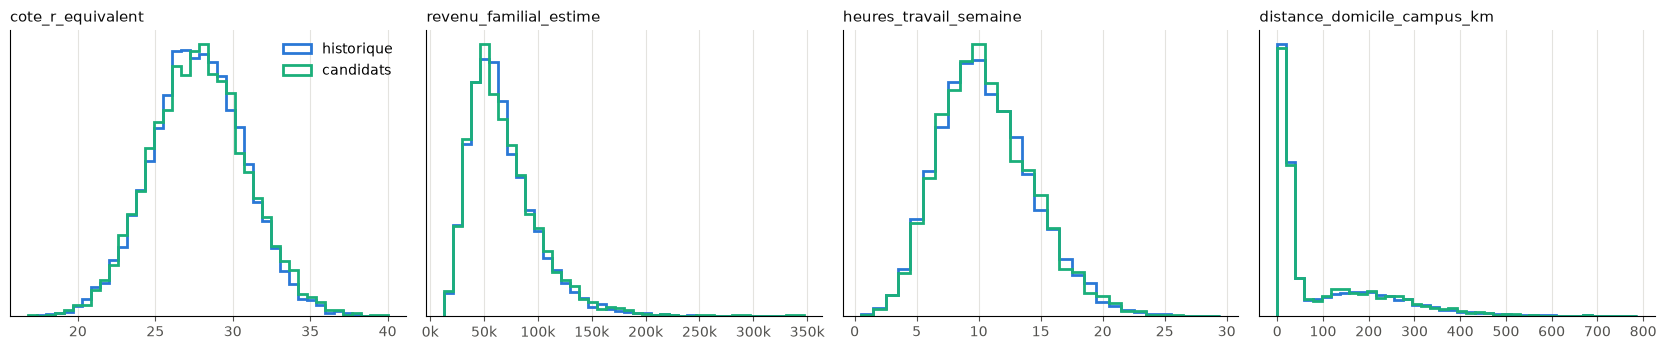

In [10]:
def comparer_jeux(a, b, colonnes):
    """Moyennes des deux jeux et test de Kolmogorov-Smirnov, par colonne numerique."""
    lignes = {}
    for col in colonnes:
        test = ks_2samp(a[col], b[col])
        lignes[col] = {'moyenne_historique': a[col].mean(), 'moyenne_candidats': b[col].mean(),
                       'ks_statistique': test.statistic, 'ks_p_valeur': test.pvalue}
    return pd.DataFrame(lignes).T


print(comparer_jeux(demandes, candidats, NUMERIQUES + BINAIRES).round(4))
print()
for col in ['groupe', 'region_administrative', 'programme_etudes']:
    print(pd.concat({'historique': demandes[col].value_counts(normalize=True),
                     'candidats': candidats[col].value_counts(normalize=True)}, axis=1).round(3))
    print()
tracer_distributions(pd.concat([demandes.assign(jeu='historique'), candidats.assign(jeu='candidats')]),
                     NUMERIQUES, groupe='jeu', couleurs=COULEURS_JEU)

**Lecture.** Les candidats suivent la même distribution que l'historique : toutes les p-valeurs
de Kolmogorov-Smirnov sont supérieures à 0.3, et les proportions par région et par programme diffèrent
de moins de 2 points. Il n'y a pas de dérive de distribution : ce qui est appris sur l'historique
s's'applique aux 4 000 candidats. En production, ce même test sert de premier indicateur de dérive pour
le plan de surveillance.